<a href="https://colab.research.google.com/github/miftahulhdd/MiftahulHudaAmri_2411533005_ML2526/blob/main/Integrasi_PCA_dengan_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [3]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model tanpa pca

In [5]:
log = LogisticRegression(max_iter=5000)
log.fit(X_train_scaled, y_train)

acc_log = accuracy_score(y_test, log.predict(X_test_scaled))
print("Logistic (No PCA):", acc_log)

Logistic (No PCA): 0.9736842105263158


In [6]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

acc_knn = accuracy_score(y_test, knn.predict(X_test_scaled))
print("KNN (No PCA):", acc_knn)

KNN (No PCA): 0.9473684210526315


In [7]:
svm = SVC(kernel='rbf')
svm.fit(X_train_scaled, y_train)

acc_svm = accuracy_score(y_test, svm.predict(X_test_scaled))
print("SVM (No PCA):", acc_svm)

SVM (No PCA): 0.9824561403508771


Model Dengan PCA (10 Komponen)

In [8]:
pca = PCA(n_components=10)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [9]:
log_pca = LogisticRegression(max_iter=5000)
log_pca.fit(X_train_pca, y_train)

acc_log_pca = accuracy_score(y_test, log_pca.predict(X_test_pca))
print("Logistic + PCA:", acc_log_pca)

Logistic + PCA: 0.9824561403508771


In [10]:
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

acc_knn_pca = accuracy_score(y_test, knn_pca.predict(X_test_pca))
print("KNN + PCA:", acc_knn_pca)

KNN + PCA: 0.956140350877193


In [11]:
svm_pca = SVC(kernel='rbf')
svm_pca.fit(X_train_pca, y_train)

acc_svm_pca = accuracy_score(y_test, svm_pca.predict(X_test_pca))
print("SVM + PCA:", acc_svm_pca)

SVM + PCA: 0.9649122807017544


Cross Validation

In [12]:
cv_log = cross_val_score(log, X_train_scaled, y_train, cv=5).mean()
cv_log_pca = cross_val_score(log_pca, X_train_pca, y_train, cv=5).mean()

print("CV Logistic:", cv_log)
print("CV Logistic + PCA:", cv_log_pca)

CV Logistic: 0.9736263736263737
CV Logistic + PCA: 0.9758241758241759


In [13]:
cv_knn = cross_val_score(knn, X_train_scaled, y_train, cv=5).mean()
cv_knn_pca = cross_val_score(knn_pca, X_train_pca, y_train, cv=5).mean()

print("CV KNN:      ", cv_knn)
print("CV KNN + PCA:", cv_knn_pca)

CV KNN:       0.9604395604395606
CV KNN + PCA: 0.9538461538461538


In [14]:
cv_svm = cross_val_score(svm, X_train_scaled, y_train, cv=5).mean()
cv_svm_pca = cross_val_score(svm_pca, X_train_pca, y_train, cv=5).mean()

print("CV SVM:      ", cv_svm)
print("CV SVM + PCA:", cv_svm_pca)

CV SVM:       0.9758241758241759
CV SVM + PCA: 0.9736263736263737


eksperimen jumlah komponen

5 komponen

In [15]:
# PCA dengan 5 Komponen
pca_5 = PCA(n_components=5)
X_train_pca5 = pca_5.fit_transform(X_train_scaled)
X_test_pca5 = pca_5.transform(X_test_scaled)

# Logistic Regression
log_5 = LogisticRegression(max_iter=5000)
log_5.fit(X_train_pca5, y_train)
print("Logistic + PCA (5 Komponen):", accuracy_score(y_test, log_5.predict(X_test_pca5)))

# KNN
knn_5 = KNeighborsClassifier(n_neighbors=5)
knn_5.fit(X_train_pca5, y_train)
print("KNN + PCA (5 Komponen):", accuracy_score(y_test, knn_5.predict(X_test_pca5)))

# SVM
svm_5 = SVC(kernel='rbf')
svm_5.fit(X_train_pca5, y_train)
print("SVM + PCA (5 Komponen):", accuracy_score(y_test, svm_5.predict(X_test_pca5)))

Logistic + PCA (5 Komponen): 0.9824561403508771
KNN + PCA (5 Komponen): 0.956140350877193
SVM + PCA (5 Komponen): 0.9649122807017544


pca 10 komponen sudah ada diatas

15 komponen

In [16]:
# PCA dengan 15 Komponen
pca_15 = PCA(n_components=15)
X_train_pca15 = pca_15.fit_transform(X_train_scaled)
X_test_pca15 = pca_15.transform(X_test_scaled)

# Logistic Regression
log_15 = LogisticRegression(max_iter=5000)
log_15.fit(X_train_pca15, y_train)
print("Logistic + PCA (15 Komponen):", accuracy_score(y_test, log_15.predict(X_test_pca15)))

# KNN
knn_15 = KNeighborsClassifier(n_neighbors=5)
knn_15.fit(X_train_pca15, y_train)
print("KNN + PCA (15 Komponen):", accuracy_score(y_test, knn_15.predict(X_test_pca15)))

# SVM
svm_15 = SVC(kernel='rbf')
svm_15.fit(X_train_pca15, y_train)
print("SVM + PCA (15 Komponen):", accuracy_score(y_test, svm_15.predict(X_test_pca15)))

Logistic + PCA (15 Komponen): 0.9912280701754386
KNN + PCA (15 Komponen): 0.9473684210526315
SVM + PCA (15 Komponen): 0.9824561403508771


pca 90% variance

In [17]:
# PCA dengan 90% Variance
pca_90 = PCA(n_components=0.90)
X_train_pca90 = pca_90.fit_transform(X_train_scaled)
X_test_pca90 = pca_90.transform(X_test_scaled)

print(f"Jumlah komponen aktual (90% Variance): {pca_90.n_components_}\n")

# Logistic Regression
log_90 = LogisticRegression(max_iter=5000)
log_90.fit(X_train_pca90, y_train)
print("Logistic + PCA (90% Var):", accuracy_score(y_test, log_90.predict(X_test_pca90)))

# KNN
knn_90 = KNeighborsClassifier(n_neighbors=5)
knn_90.fit(X_train_pca90, y_train)
print("KNN + PCA (90% Var):", accuracy_score(y_test, knn_90.predict(X_test_pca90)))

# SVM
svm_90 = SVC(kernel='rbf')
svm_90.fit(X_train_pca90, y_train)
print("SVM + PCA (90% Var):", accuracy_score(y_test, svm_90.predict(X_test_pca90)))

Jumlah komponen aktual (90% Variance): 7

Logistic + PCA (90% Var): 0.9824561403508771
KNN + PCA (90% Var): 0.9473684210526315
SVM + PCA (90% Var): 0.9736842105263158


tugas individu

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

print("=== UJI PCA 2 KOMPONEN & DECISION TREE ===")
# PCA dengan 2 Komponen saja
pca_2 = PCA(n_components=2)
X_train_pca2 = pca_2.fit_transform(X_train_scaled)
X_test_pca2 = pca_2.transform(X_test_scaled)

# Decision Tree Tanpa PCA (Baseline)
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)
acc_dt = accuracy_score(y_test, dt.predict(X_test_scaled))
print(f"Decision Tree (No PCA): {acc_dt:.4f}")

# Decision Tree + PCA 2 Komponen
dt_pca2 = DecisionTreeClassifier(random_state=42)
dt_pca2.fit(X_train_pca2, y_train)
acc_dt_pca2 = accuracy_score(y_test, dt_pca2.predict(X_test_pca2))
print(f"Decision Tree + PCA (2 Komp): {acc_dt_pca2:.4f}")

# Logistic Regression + PCA 2 Komponen (Sebagai pembanding penurunan)
log_pca2 = LogisticRegression(max_iter=5000)
log_pca2.fit(X_train_pca2, y_train)
acc_log_pca2 = accuracy_score(y_test, log_pca2.predict(X_test_pca2))
print(f"Logistic + PCA (2 Komp): {acc_log_pca2:.4f}")
print(" ")
print("=== GRIDSEARCH CV PADA KNN ===")
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_knn.fit(X_train_pca, y_train) # Menggunakan PCA 10 komponen

print("Parameter terbaik KNN:", grid_knn.best_params_)
print(f"Akurasi CV terbaik: {grid_knn.best_score_:.4f}")

# Evaluasi model terbaik di data test
best_knn = grid_knn.best_estimator_
acc_best_knn = accuracy_score(y_test, best_knn.predict(X_test_pca))
print(f"Akurasi Test set (Best KNN): {acc_best_knn:.4f}")

=== UJI PCA 2 KOMPONEN & DECISION TREE ===
Decision Tree (No PCA): 0.9474
Decision Tree + PCA (2 Komp): 0.9561
Logistic + PCA (2 Komp): 0.9912
 
=== GRIDSEARCH CV PADA KNN ===
Parameter terbaik KNN: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'uniform'}
Akurasi CV terbaik: 0.9692
Akurasi Test set (Best KNN): 0.9386


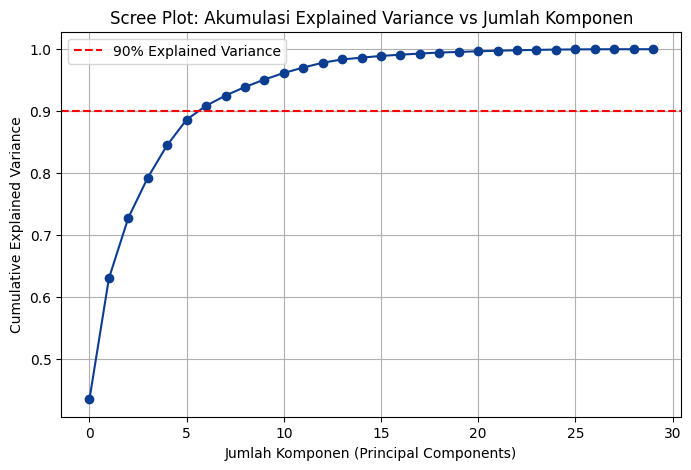

In [24]:
# --- GRAFIK EXPLAINED VARIANCE ---
pca_full = PCA().fit(X_train_scaled)

plt.figure(figsize=(8, 5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_), marker='o', linestyle='-', color='#0B3D91')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Explained Variance')
plt.xlabel('Jumlah Komponen (Principal Components)')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot: Akumulasi Explained Variance vs Jumlah Komponen')
plt.legend(loc='best')
plt.grid(True)
plt.show()